# El modelo X-13 de BCR: cómo funciona y réplica

**Proyecto BCR · Lab 2 · Épica E4 (SCRUM-23)**

BCR estima la producción de biocombustibles con **X-13ARIMA-SEATS**, un
programa libre del Census de EE.UU. No es un modelo propio: es una
herramienta estándar que usan institutos de estadística de todo el mundo
(INDEC incluido). Acá lo replicamos para tener el **número exacto a superar**.

> **Config exacta de BCR.** Usamos los archivos `.spc` que nos pasó BCR
> (en `referencia/spc/`): el modelo se ajusta **desde 2013** (`modelspan`),
> con corrección de **días hábiles y Pascua** (`aictest=(td easter)`) y los
> órdenes de su `automdl`. Con esto la réplica reproduce su corrida **exacta**
> (0,0% de diferencia). Dato clave que surge de su config: para **biodiesel el
> modelo elegido NO tiene componente estacional** (es un `(2 0 1)`), pese a que
> el EDA muestra estacionalidad fuerte — ahí está el margen de mejora.

## ¿Qué hace X-13 por dentro?

Trabaja en dos grandes etapas:

1. **regARIMA (la parte de pronóstico).** Ajusta a la serie un modelo
   **SARIMA** (ARIMA con componente estacional) y, de paso, puede corregir
   outliers y efectos de calendario. Elige el modelo **automáticamente**
   (procedimiento `automdl`). Con ese modelo, **extiende la serie** hacia
   adelante: ese es el pronóstico del mes que falta.

2. **Ajuste estacional (X-11).** Descompone la serie en tres partes:
   **tendencia-ciclo** + **estacionalidad** + **irregular**. Al sacarle la
   estacionalidad, queda la serie "desestacionalizada", que es la que BCR
   publica como variación mensual en el IACA.

El `pip install x13binary` trae el motor; no hace falta instalar nada más.

In [1]:
# Requisitos: pip install x13binary statsmodels pandas numpy matplotlib
import subprocess, tempfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from x13binary import find_x13_bin

X13 = find_x13_bin()
plt.rcParams["figure.figsize"] = (12, 4)
print("Binario X-13:", X13)

Binario X-13: /usr/local/bin/x13as_html


## 1. Correr X-13 sobre la producción de biodiesel

Le pasamos la serie cruda y le pedimos: transformación logarítmica (como
usa BCR para biodiesel), selección automática del modelo, descomposición
(`x11`) y un pronóstico a un mes. Guardamos las tablas de componentes para
graficarlas.

In [2]:
def correr_x13(serie, log=True):
    """Corre X-13 y devuelve (texto_salida, componentes, pronóstico).

    componentes: DataFrame con seasonal (d10), seasadj (d11),
    trend (d12), irregular (d13). pronóstico: valor a un mes.
    """
    vals = serie.values
    primero = serie.index[0]
    start = f"{primero.year}.{primero.month}"
    chunks = [vals[i:i+10] for i in range(0, len(vals), 10)]
    datalines = "\n".join("    " + " ".join(f"{v:.3f}" for v in c) for c in chunks)
    tr = "log" if log else "none"
    # Config real de BCR (referencia/spc/): modelo desde 2013, días hábiles/Pascua, órdenes del automdl.
    modelspan = " modelspan=(2013.1, )\n" if (primero.year, primero.month) <= (2013, 1) else ""
    spec = (
        f"series{{\n start={start}\n period=12\n{modelspan} data=(\n{datalines}\n )\n}}\n"
        f"transform{{ function={tr} }}\n"
        "regression{ aictest=(td easter) }\n"
        "automdl{ maxdiff=(2 1) maxorder=(4 2) }\n"
        "x11{ save=(d10 d11 d12 d13) }\n"
        "forecast{ maxlead=1 save=(fct) }\n"
    )
    tmp = Path(tempfile.mkdtemp()); base = tmp / "r"
    base.with_suffix(".spc").write_text(spec)
    subprocess.run([X13, str(base)], cwd=tmp, capture_output=True, text=True, timeout=60)

    import re
    texto = re.sub("<[^>]*>", "", (base.with_suffix(".html")).read_text(encoding="latin-1"))

    def leer_tabla(ext):
        p = base.with_suffix(ext)
        if not p.exists():
            return None
        df = pd.read_csv(p, sep="\t", skiprows=2, names=["date", ext[1:]])
        df["date"] = pd.to_datetime(df["date"].astype(int).astype(str), format="%Y%m")
        return df.set_index("date")[ext[1:]]

    comp = pd.concat([leer_tabla(e) for e in [".d10", ".d11", ".d12", ".d13"]], axis=1)
    comp.columns = ["estacional", "desestacionalizada", "tendencia", "irregular"]

    fct = base.with_suffix(".fct")
    pron = np.nan
    if fct.exists():
        linea = [l for l in fct.read_text().splitlines() if l and l[0].isdigit()][-1]
        pron = float(linea.split("\t")[1].replace("E", "e"))
    return texto, comp, pron


bd = (pd.read_csv("../data/produccion_biodiesel.csv", parse_dates=["fecha"])
        .sort_values("fecha").set_index("fecha"))
serie = bd["produccion_tn"]

texto, comp, pron = correr_x13(serie, log=True)
print(f"Pronóstico X-13 para el mes siguiente: {pron:,.0f} toneladas")

Pronóstico X-13 para el mes siguiente: 146,239 toneladas


### El modelo que eligió

Con la ventana desde 2013, X-13 elige para biodiesel un modelo **sin
componente estacional** (un `(2 0 1)`, sin la parte `(P D Q)`). Es decir: el
modelo de BCR **no modela la estacionalidad**, aunque el EDA la marcó como
fuerte. Ese es, probablemente, el margen de mejora más directo.

In [3]:
import re
# El patrón acepta modelos estacionales (d d d)(d d d) y NO estacionales (d d d).
patron = r"\(\d \d \d\)(\(\d \d \d\))?"
final = None
for linea in texto.split("\n"):
    if "final" in linea.lower() and re.search(patron, linea):
        final = linea.strip()
if final is None:
    matches = [l.strip() for l in texto.split("\n") if re.search(r"ARIMA Model", l)]
    final = matches[-1] if matches else "(no encontrado)"
print("Modelo final elegido:", final)
print("(biodiesel: (2 0 1), sin parte estacional → no usa la estacionalidad)")

Modelo final elegido: Final automatic model choice : (2 0 1)
(biodiesel: (2 0 1), sin parte estacional → no usa la estacionalidad)


### La descomposición

Así separa X-13 la serie: la producción observada, la tendencia de fondo, el
patrón estacional que se repite cada año, y lo irregular (lo que no explica
ni tendencia ni estacionalidad).

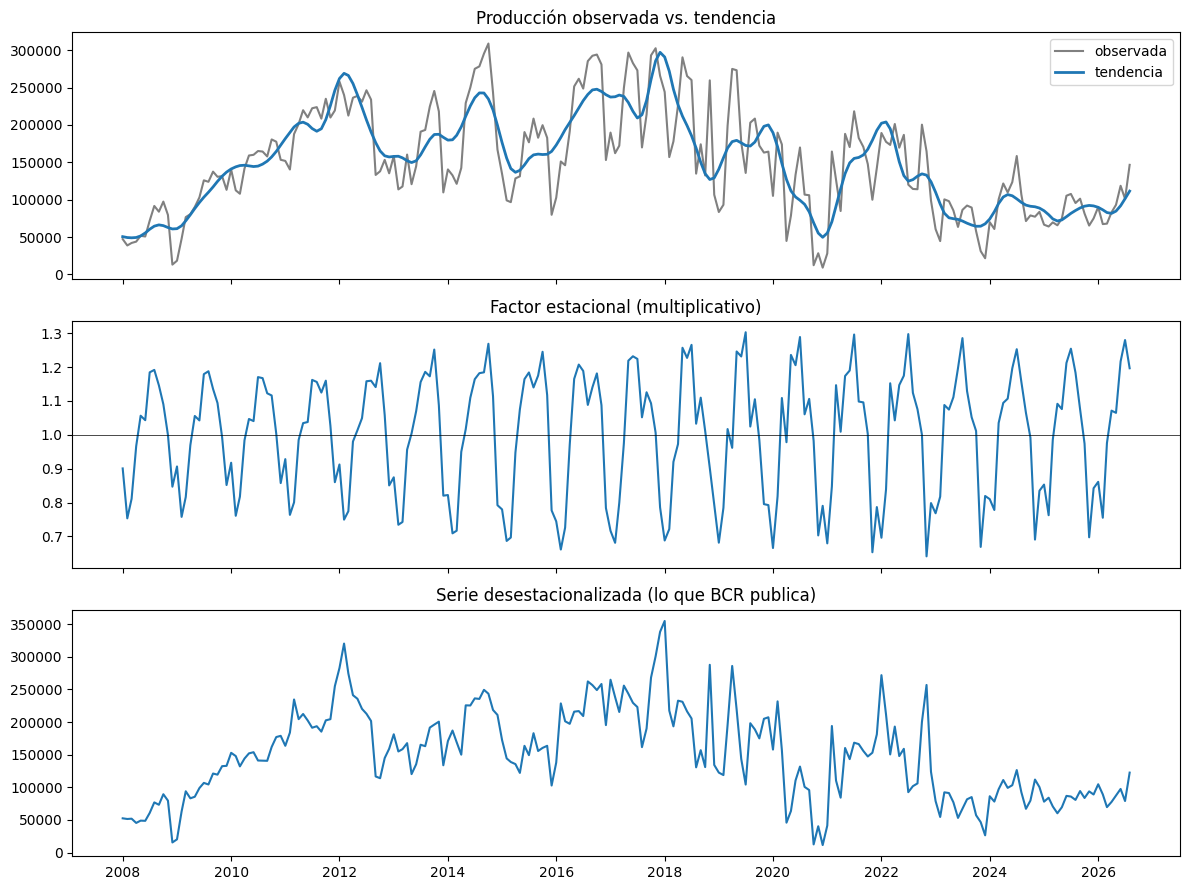

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(serie.index, serie.values, label="observada", color="gray")
axes[0].plot(comp.index, comp["tendencia"], label="tendencia", lw=2)
axes[0].set_title("Producción observada vs. tendencia"); axes[0].legend()
axes[1].plot(comp.index, comp["estacional"]); axes[1].axhline(1, color="k", lw=0.5)
axes[1].set_title("Factor estacional (multiplicativo)")
axes[2].plot(comp.index, comp["desestacionalizada"])
axes[2].set_title("Serie desestacionalizada (lo que BCR publica)")
plt.tight_layout(); plt.show()

## 2. Réplica walk-forward: ¿qué tan bien estima?

Corrimos X-13 mes a mes (cada mes se reentrena con los datos anteriores y
predice el siguiente) sobre las cuatro series, usando el **mismo protocolo de
evaluación** (`scripts/evaluacion.py`) que los baselines. El cálculo completo
está en `scripts/replica_x13.py`; acá cargamos los resultados de `results/` y
los comparamos contra los baselines.

Ventana de test: septiembre 2025 → agosto 2026 (12 meses).

> Correr el walk-forward de X-13 tarda un par de minutos (muchas corridas),
> por eso se deja precalculado en `results/x13.csv`.

In [5]:
from pathlib import Path

# Usamos la tabla de integración (baselines de Andrés + X-13, armada por
# scripts/comparacion.py). Si todavía no está, caemos al x13.csv solo.
comp_path = Path("../results/comparacion.csv")
if comp_path.exists():
    comp_df = pd.read_csv(comp_path)
else:
    comp_df = pd.read_csv("../results/x13.csv")
    print("(falta results/comparacion.csv: corré scripts/comparacion.py; muestro solo X-13)\n")
tabla_mape = comp_df.pivot_table(index="serie", columns="modelo", values="MAPE_pct").round(1)
tabla_signo = comp_df.pivot_table(index="serie", columns="modelo", values="acierto_signo_pct").round(0)
print("MAPE por serie y modelo (menor = mejor):")
print(tabla_mape.to_string())
print("\nAcierto de signo (mayor = mejor):")
print(tabla_signo.to_string())

MAPE por serie y modelo (menor = mejor):
modelo           naive  naive_estacional   x13
serie                                         
biodiesel         18.2              15.8  21.0
bioetanol_cana    28.4              15.5  16.4
bioetanol_maiz     6.6               6.6   6.0
bioetanol_total   10.3               5.0   7.8

Acierto de signo (mayor = mejor):
modelo           naive  naive_estacional   x13
serie                                         
biodiesel          0.0              58.0  67.0
bioetanol_cana     0.0              92.0  83.0
bioetanol_maiz     0.0              58.0  58.0
bioetanol_total    0.0              67.0  75.0


## 3. Criterio del DoD: la predicción de agosto 2026

El DoD pide comparar la predicción de agosto 2026 contra la del Excel de BCR.
BCR la estima con datos hasta julio 2026; nuestra réplica hace lo mismo (es el
último mes del walk-forward). Los números (en `results/pronostico_agosto2026.csv`):

In [6]:
pa = pd.read_csv("../results/pronostico_agosto2026.csv")
print(pa.to_string(index=False))

          serie  mi_pronostico  bcr_winx13  real_publicado  dif_vs_bcr_pct
      biodiesel         103923      103922          146604             0.0
bioetanol_total         140394      140394          139521             0.0


Con la config real del `.spc`, **las dos predicciones coinciden con BCR al
kilo** (diferencia 0,0% en biodiesel y en bioetanol). La réplica reproduce su
corrida exacta, no solo el método. La descomposición histórica también matchea
al **0,0%** (ver `comparar_bcr_x13.py`).

## 4. Conclusiones

Con la **configuración real de BCR** (su `.spc`), el X-13 pierde contra un
baseline trivial en **3 de las 4 series**:

1. **El X-13 real de BCR es superado por el naive estacional** en biodiesel,
   bioetanol total y caña. Solo gana en maíz (la serie más plana). Es el
   argumento central del proyecto: hay margen de mejora real.
2. **Biodiesel es el caso más claro**: X-13 da 21% de MAPE, peor que el naive
   estacional (16%). Y la causa es concreta: su modelo **no usa la
   estacionalidad** (elige un `(2 0 1)`), que el EDA marcó como fuerte.
3. **Acierto de signo** de X-13: mejor en caña (83%) y biodiesel (67%).

**Benchmark a superar por serie** (el mejor entre el X-13 real y los
baselines, test sep-2025 → ago-2026):

| Serie | Mejor actual | MAPE |
|---|---|---|
| Biodiesel | naive estacional | ~15,8% |
| Bioetanol total | naive estacional | ~5,0% |
| Bioetanol maíz | X-13 | ~6,0% |
| Bioetanol caña | naive estacional | ~15,5% |

Nuestros modelos (SARIMAX, ML, LSTM) tienen que mejorar **el mejor de cada
fila**.

> **Dos "X-13" posibles.** El de BCR (config `.spc`) da 21% en biodiesel: es
> el benchmark real, lo que usan en producción. Un X-13 con `automdl` libre
> (sin fijar la ventana ni los regresores) da ~13%: muestra que parte de la
> mejora es solo *afinar mejor la config del X-13* (p. ej. dejarlo captar la
> estacionalidad), antes de ir a modelos más complejos.